# Tarea 1 - Notebook de codigo

**Nombres**: Martin Gottschalk, Marcial Ibañez


## Setup inicial

In [110]:
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
import os
import re
from getpass import getpass
import requests
from IPython.display import display

In [111]:
# -------------------------
# Configuracion API BCCh
# -------------------------
CATALOGO_URL = "https://si3.bcentral.cl/estadisticas/Principal1/Web_Services/Webservices/series.xlsx"
API_URL = "https://si3.bcentral.cl/SieteRestWS/SieteRestWS.ashx"


def obtener_credenciales_bcch():
    """
    Obtiene credenciales sin hardcodearlas en el notebook.

    Orden de lectura:
    1) Variables de entorno BCCH_USER y BCCH_PASS.
    2) Archivo local (no versionado) indicado en BCCH_CREDENTIALS_FILE,
       o por defecto .bcch_credentials.txt en la carpeta del notebook.
       Formato del archivo:
         linea 1: usuario
         linea 2: password
    """
    user = os.getenv("BCCH_USER", "").strip()
    password = os.getenv("BCCH_PASS", "").strip()

    if user and password:
        return user, password

    cred_file = os.getenv("BCCH_CREDENTIALS_FILE", ".bcch_credentials.txt")
    if os.path.exists(cred_file):
        with open(cred_file, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        if len(lines) >= 2:
            user, password = lines[0], lines[1]
            os.environ["BCCH_USER"] = user
            os.environ["BCCH_PASS"] = password
            return user, password

    raise RuntimeError(
        "No se encontraron credenciales BCCh. "
        "Configura BCCH_USER y BCCH_PASS en el entorno del kernel, "
        "o crea .bcch_credentials.txt (usuario en linea 1, password en linea 2)."
    )

## 1. PIB real por región y actividad económica


In [112]:
import time

#Regiones elegidas para el analisis
REGIONES_OBJETIVO = {
    "13": "Metropolitana de Santiago",
    "02": "Antofagasta",
}

#Menos actividades para evitar tiempos excesivos de espera en la API
ACTIVIDADES_CODIGO = [
    "01", "02", "03", "04", "05", "06", "07", "08", "09", "10"
]

#Limites de ejecucion para evitar que el notebook quede "pegado"
REQUEST_TIMEOUT = 8
MAX_RETRIES = 2
MAX_SECONDS_PER_REGION = 40


def construir_series_id(region_code, activity_code="Z"):
    return f"F035.PIB.FLU.R.CLP.2018.{activity_code}.Z.Z.{region_code}.0.A"


def obtener_etiqueta_actividad(descrip_esp, activity_code):
    if descrip_esp:
        txt = re.sub(r"^PIB\s+", "", str(descrip_esp), flags=re.IGNORECASE).strip()
        return txt.split(",")[0].strip()
    return f"Actividad {activity_code}"


def request_json_with_retry(url, params, timeout=REQUEST_TIMEOUT, max_retries=MAX_RETRIES):
    for i in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=timeout)
            response.raise_for_status()
            return response.json()
        except requests.RequestException:
            if i < max_retries - 1:
                time.sleep(1)
    raise RuntimeError("Fallo de conexion con API BCCh (timeout/reintentos agotados).")


def consultar_serie_bcch(series_id, user, password):
    params = {
        "user": user,
        "pass": password,
        "timeseries": series_id,
        "function": "GetSeries",
    }

    payload = request_json_with_retry(API_URL, params=params)

    if payload.get("Codigo", -1) != 0:
        raise RuntimeError(f"Error API en {series_id}: {payload.get('Descripcion', 'Sin descripcion')}")

    series_meta = payload.get("Series") or {}
    descrip_esp = series_meta.get("descripEsp", "")
    obs = series_meta.get("Obs") or []

    if not obs:
        return pd.DataFrame(columns=["date", "value", "seriesId"]), descrip_esp

    df = pd.DataFrame(obs)
    df["date"] = pd.to_datetime(df["indexDateString"], dayfirst=True, errors="coerce")
    df["value"] = pd.to_numeric(
        df["value"].astype(str).str.replace(",", ".", regex=False),
        errors="coerce",
    )
    df["seriesId"] = series_id
    return df[["date", "value", "seriesId"]].dropna(subset=["value", "date"]), descrip_esp


def seleccionar_valor_objetivo(df_serie, target_year=2025):
    if df_serie.empty:
        return None, None

    s = df_serie.copy()
    s["year"] = s["date"].dt.year

    exact = s[s["year"] == target_year]
    if not exact.empty:
        row = exact.sort_values("date").iloc[-1]
        return float(row["value"]), int(row["year"])

    hist = s[s["year"] <= target_year]
    if not hist.empty:
        row = hist.sort_values("date").iloc[-1]
        return float(row["value"]), int(row["year"])

    row = s.sort_values("date").iloc[0]
    return float(row["value"]), int(row["year"])



# 1 Credenciales

usuario, clave = obtener_credenciales_bcch()
cache_series = {}


# 2 PIB total para las 2 regiones

registros_region = []
errores_region = []

for region_code, region_name in REGIONES_OBJETIVO.items():
    sid_total = construir_series_id(region_code, "Z")
    try:
        if sid_total not in cache_series:
            cache_series[sid_total] = consultar_serie_bcch(sid_total, usuario, clave)

        datos, _ = cache_series[sid_total]
        valor, anio_usado = seleccionar_valor_objetivo(datos, target_year=2025)

        if valor is not None:
            registros_region.append(
                {
                    "regionCode": region_code,
                    "region": region_name,
                    "pib_objetivo": valor,
                    "anio_usado": anio_usado,
                }
            )
    except Exception as e:
        errores_region.append((sid_total, str(e)))

if not registros_region:
    ejemplo_error = errores_region[0][1] if errores_region else "sin detalle"
    raise ValueError(
        "No se recuperaron observaciones para las regiones seleccionadas. "
        f"Error: {ejemplo_error}"
    )

pib_2reg = pd.DataFrame(registros_region).dropna(subset=["pib_objetivo"]).copy()
pib_2reg = pib_2reg[pib_2reg["pib_objetivo"] > 0].sort_values("pib_objetivo", ascending=False)

if pib_2reg.empty:
    raise ValueError("No se obtuvieron datos validos para las 2 regiones seleccionadas.")


# 3 Grafico de pie: solo 2 regiones

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(
    pib_2reg["pib_objetivo"],
    labels=pib_2reg["region"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("PIB real regional (Metropolitana vs Antofagasta)")
plt.tight_layout()
plt.show()

pib_2reg["participacion_%"] = 100 * pib_2reg["pib_objetivo"] / pib_2reg["pib_objetivo"].sum()
display(pib_2reg[["region", "anio_usado", "pib_objetivo", "participacion_%"]].reset_index(drop=True))


# 4 Desagregacion por actividad para las 2 regiones

print("Regiones seleccionadas:")
for _, r in pib_2reg.iterrows():
    print(f"- {r['region']} (codigo {r['regionCode']})")

for _, reg in pib_2reg.iterrows():
    cod_region = reg["regionCode"]
    nombre_region = reg["region"]

    filas = []
    t0 = time.time()

    for act_code in ACTIVIDADES_CODIGO:
        if time.time() - t0 > MAX_SECONDS_PER_REGION:
            print(f"\nCorte por tiempo en {nombre_region}: se muestran resultados parciales.")
            break

        sid = construir_series_id(cod_region, act_code)
        try:
            if sid not in cache_series:
                cache_series[sid] = consultar_serie_bcch(sid, usuario, clave)

            datos, descrip_esp = cache_series[sid]
            valor, anio_usado = seleccionar_valor_objetivo(datos, target_year=2025)

            if valor is not None and valor > 0:
                filas.append(
                    {
                        "actividad": obtener_etiqueta_actividad(descrip_esp, act_code),
                        "valor": valor,
                        "anio_usado": anio_usado,
                    }
                )
        except Exception:
            continue

    act = pd.DataFrame(filas)
    if act.empty:
        print(f"\nNo se pudieron recuperar actividades para {nombre_region}.")
        continue

    act = act.groupby(["actividad", "anio_usado"], as_index=False)["valor"].sum()
    act = act.sort_values("valor", ascending=False).head(8)
    act["participacion_%"] = 100 * act["valor"] / act["valor"].sum()

    plt.figure(figsize=(10, 5))
    sns.barplot(data=act, x="valor", y="actividad", hue="actividad", palette="crest", legend=False)
    plt.title(f"Top actividades - {nombre_region}")
    plt.xlabel("PIB real")
    plt.ylabel("Actividad")
    plt.tight_layout()
    plt.show()

    display(act[["actividad", "anio_usado", "valor", "participacion_%"]].reset_index(drop=True))

    print(f"\nPrincipales aportes en {nombre_region}:")
    for _, a in act.head(3).iterrows():
        print(f"- {a['actividad']}: {a['participacion_%']:.1f}%")


# 5 Interpretacion global

lider = pib_2reg.iloc[0]
print("\nInterpretacion global:")
print(f"- Entre estas dos regiones, {lider['region']} aporta la mayor participacion del PIB observado. Esto se debe a que es la region mas poblada y con mayor actividad economica del pais, concentrando gran parte de los servicios, comercio e industria nacional.")
if (pib_2reg["anio_usado"] != 2025).any():
    print("- Nota: en algunas series se uso el ultimo año disponible <= 2025. Además se demora un poco en cargar, paciencia por favor.")
if errores_region:
    print(f"- Aviso: {len(errores_region)} series no pudieron descargarse y se omitieron.")

# Limpieza basica de variables sensibles en memoria
del clave

ValueError: No se recuperaron observaciones para las regiones seleccionadas. Error: Error API en F035.PIB.FLU.R.CLP.2018.Z.Z.Z.13.0.A: Invalid username or password

## 2. PIB Nominal y real


A partir de la siguiente tabla calcule lo el PIB nominal y real (con base año 0) de cada
año, y calcule la tasa de crecimiento.

**RESPUESTA EN EL PDF**

## 3. Canasta IPC

Realice un gráfico de pie con las 13 divisiones de la canasta IPC 2026, luego seleccione 2
de ellas y explique la incidencia que tuvieron en la inflación de febrero 2026 (Boletı́n IPC).

## 4. Inflación

**RESPUESTA EN EL PDF**

## 5. Mercado del dinero


Obtenga, a través de la API de yfinance, el tipo de cambio CLP/USD de los últimos 5
años. Junto con esto, obtenga la TPM de la API del banco central. Obtenga la correlación
y grafique ambos. A partir de esto interprete y explique la relación entre las dos.
[15 PUNTOS]

- a) Muestre en un mismo gráfico ambas series y obtenga la correlación entre las 2.
- b) Añada al análisis el precio del cobre en el mismo periodo, también obtenido de yfinance, y obtenga las correlaciones.
- c) Interprete sus resultados, y explique una posible relación entre las 3.


### a) Muestre en un mismo gráfico ambas series y obtenga la correlación entre las 2.


- Cambio CLP/USD

In [ ]:
import yfinance as yf

# Define the ticker symbol
ticker_symbol = "clpusd=x"
# Create a Ticker object
ticker = yf.Ticker(ticker_symbol)
# Fetch historical market data
historical_data = ticker.history(period="5y")  # data for the last 5 years
print("Historical Data:")
historical_data.head()

Historical Data:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-04-05 00:00:00+01:00,0.001395,0.001407,0.001389,0.001395,0,0.0,0.0
2021-04-06 00:00:00+01:00,0.001387,0.001398,0.001385,0.001387,0,0.0,0.0
2021-04-07 00:00:00+01:00,0.001394,0.001406,0.001393,0.001394,0,0.0,0.0
2021-04-08 00:00:00+01:00,0.001402,0.001416,0.001402,0.001402,0,0.0,0.0
2021-04-09 00:00:00+01:00,0.001413,0.001415,0.001404,0.001413,0,0.0,0.0


- TPM Banco Central

In [121]:
import bcchapi

siete = bcchapi.Siete(file=".bcch_credentials.txt")
df=siete.buscar("TPM")


In [140]:
# TPM (BCCh) + correlation with CLP/USD
tpm_series_id = "F022.TPM.TIN.D001.NO.Z.M"  # TPM mensual
desde = (pd.Timestamp.today() - pd.DateOffset(years=5)).strftime("%Y-%m-%d")
hasta = pd.Timestamp.today().strftime("%Y-%m-%d")

# 1) Descargar TPM desde BCCh (intento API directa + fallback bcchapi)
tpm_data = None
try:
    user_bcch, pass_bcch = obtener_credenciales_bcch()
    tpm_raw, _ = consultar_serie_bcch(tpm_series_id, user_bcch, pass_bcch)
    if not tpm_raw.empty:
        tpm_data = (
            tpm_raw[["date", "value"]]
            .rename(columns={"value": "TPM"})
            .set_index("date")
            .sort_index()
        )
except Exception as e:
    print(f"Aviso: API directa BCCh no disponible ({e}). Se usa fallback bcchapi.")

if tpm_data is None or tpm_data.empty:
    import bcchapi
    if "siete" not in globals():
        siete = bcchapi.Siete(file=".bcch_credentials.txt")

    tpm_fallback = siete.cuadro(
        series=[tpm_series_id],
        nombres=["TPM"],
        desde=desde,
        hasta=hasta
    )

    if tpm_fallback is None or tpm_fallback.empty:
        raise ValueError("No se pudo descargar TPM ni por API directa ni por bcchapi")

    # Estandarizar salida de bcchapi
    tpm_data = tpm_fallback.copy()
    if not isinstance(tpm_data.index, pd.DatetimeIndex):
        tpm_data.index = pd.to_datetime(tpm_data.index, errors="coerce")
    tpm_data = tpm_data.sort_index()
    tpm_data = tpm_data[[c for c in tpm_data.columns if c == "TPM" or pd.api.types.is_numeric_dtype(tpm_data[c])]]

    if "TPM" not in tpm_data.columns:
        tpm_col = tpm_data.columns[0]
        tpm_data = tpm_data.rename(columns={tpm_col: "TPM"})
    else:
        tpm_data = tpm_data[["TPM"]]

# Limpieza final TPM
tpm_data = tpm_data.dropna(subset=["TPM"])
tpm_data.index = pd.to_datetime(tpm_data.index).tz_localize(None)
tpm_data = tpm_data.asfreq("MS").interpolate(limit_direction="both")

# 2) Asegurar serie de tipo de cambio CLP/USD
if "clp_usd_data" not in globals():
    if "historical_data" in globals() and not historical_data.empty:
        clp_usd_data = 1 / historical_data["Close"]
    else:
        import yfinance as yf
        fx = yf.Ticker("CLPUSD=X").history(period="5y")
        if fx.empty:
            raise ValueError("No se pudo descargar CLPUSD=X desde yfinance")
        clp_usd_data = 1 / fx["Close"]

# 3) Llevar ambas series a frecuencia mensual y al mismo rango
fx_series = clp_usd_data.copy()
fx_series.index = pd.to_datetime(fx_series.index).tz_localize(None)
fx_monthly = fx_series.resample("MS").mean().to_frame(name="CLP_USD")
combo = tpm_data.join(fx_monthly, how="inner").dropna()

if combo.empty:
    raise ValueError("No hay fechas comunes entre TPM y CLP/USD")

# 4) Correlacion
corr_tpm_fx = combo["TPM"].corr(combo["CLP_USD"])
print(f"\nRango usado TPM: {desde} a {hasta}")
print(f"Observaciones mensuales comunes: {len(combo)}")

display(combo.tail(12))

Aviso: API directa BCCh no disponible (Error API en F022.TPM.TIN.D001.NO.Z.M: Invalid username or password). Se usa fallback bcchapi.

Rango usado TPM: 2021-04-03 a 2026-04-03
Observaciones mensuales comunes: 59


,TPM,CLP_USD
2025-03-01,5.00,928.916149
2025-04-01,5.00,959.896010
2025-05-01,5.00,941.718177
2025-06-01,5.00,934.445014
2025-07-01,4.98,949.203384
2025-08-01,4.75,964.623498
2025-09-01,4.75,959.186032
2025-10-01,4.75,951.475217
2025-11-01,4.75,933.173656
2025-12-01,4.64,915.371370


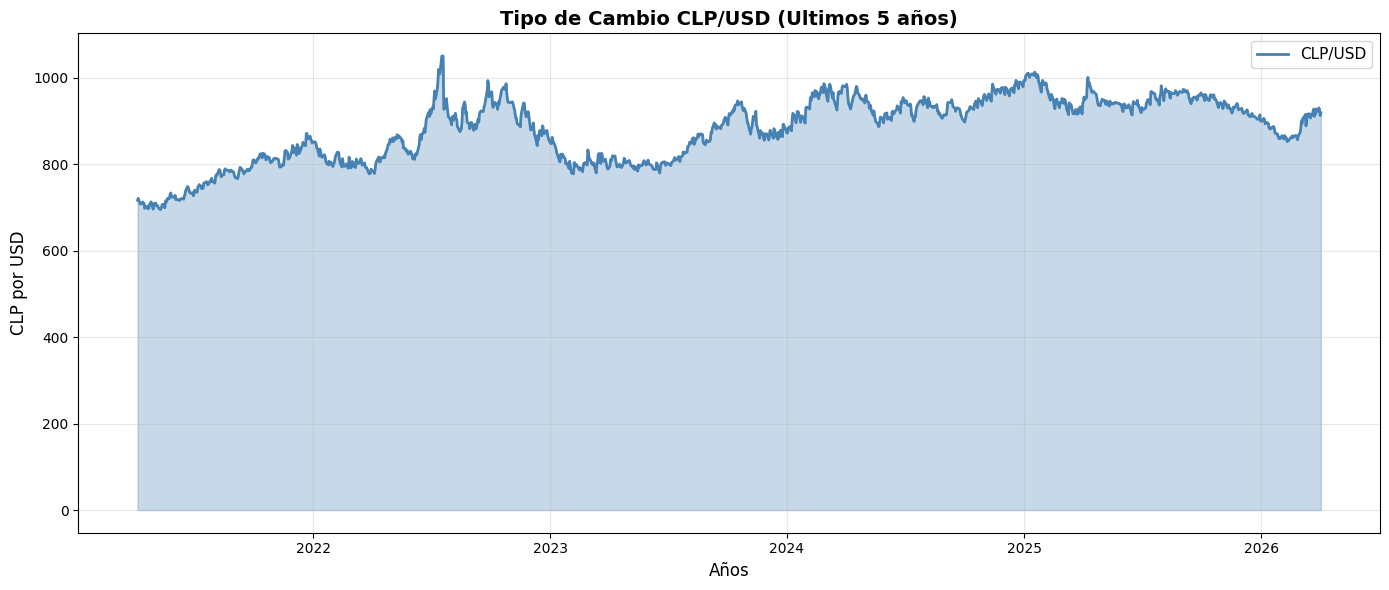


 Tipo de Cambio CLP/USD (Ultimos 5 años)
Correlacion TPM vs CLP/USD: 0.1814


In [137]:
# Convert USD/CLP to CLP/USD (invert the data)
clp_usd_data = 1 / historical_data['Close']

# a) Plot CLP/USD Exchange Rate
plt.figure(figsize=(14, 6))

# Plot: CLP/USD over time
plt.plot(clp_usd_data.index, clp_usd_data, linewidth=2, color='steelblue', label='CLP/USD')
plt.fill_between(clp_usd_data.index, clp_usd_data, alpha=0.3, color='steelblue')
plt.title('Tipo de Cambio CLP/USD (Ultimos 5 años)', fontsize=14, fontweight='bold')
plt.xlabel('Años', fontsize=12)
plt.ylabel('CLP por USD', fontsize=12)
plt.grid(True, alpha=0.3)

# Add moving averages
#ma_30 = clp_usd_data.rolling(window=30).mean()
#ma_90 = clp_usd_data.rolling(window=90).mean()
#plt.plot(clp_usd_data.index, ma_30, 'orange', linestyle='--', linewidth=1.5, label='30-day MA')
#plt.plot(clp_usd_data.index, ma_90, 'red', linestyle='--', linewidth=1.5, label='90-day MA')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print(" Tipo de Cambio CLP/USD (Ultimos 5 años)")
print("="*60)
#print(f"Current Rate: {clp_usd_data.iloc[-1]:.2f} CLP/USD")
#print(f"Highest Rate: {clp_usd_data.max():.2f} CLP/USD")
#print(f"Lowest Rate: {clp_usd_data.min():.2f} CLP/USD")
#print(f"Average Rate: {clp_usd_data.mean():.2f} CLP/USD")
#print(f"Std Deviation: {clp_usd_data.std():.2f}")
#print(f"Change (5 years): {clp_usd_data.iloc[-1] - clp_usd_data.iloc[0]:.2f} CLP/USD")
#pct_change = ((clp_usd_data.iloc[-1] - clp_usd_data.iloc[0]) / clp_usd_data.iloc[0]) * 100
#print(f"Percentage Change: {pct_change:.2f}%")

print(f"Correlacion TPM vs CLP/USD: {corr_tpm_fx:.4f}")


### b) Añada al análisis el precio del cobre en el mismo periodo, también obtenido de yfinance, y obtenga las correlaciones.

- Cobre

In [ ]:
copper_t =yf.Ticker("hg=f")
# Fetch historical market data
copper_data = copper_t.history(period="5y")  # data for the last 5 years
print("Historical Data:")
copper_data.head()

Historical Data:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-04-05 00:00:00-04:00,4.0540,4.1620,4.0540,4.1490,243,0.0,0.0
2021-04-06 00:00:00-04:00,4.1500,4.1510,4.0985,4.1265,269,0.0,0.0
2021-04-07 00:00:00-04:00,4.1175,4.1185,4.0550,4.0640,467,0.0,0.0
2021-04-08 00:00:00-04:00,4.0850,4.1035,4.0850,4.1035,366,0.0,0.0
2021-04-09 00:00:00-04:00,4.0885,4.0885,4.0505,4.0505,518,0.0,0.0


### c) Interprete sus resultados, y explique una posible relación entre las 3.

**RESPUESTA EN EL PDF**

## 6. Oferta, demanda y tipo de cambio


### 6.1. Equilibrio Inicial

**Equilibrio obtenido** = 10

Grafica

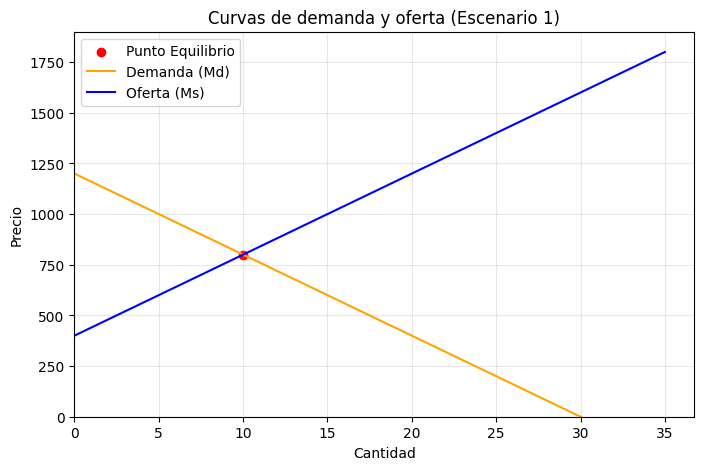

In [ ]:
#curva Demanda CLP (Md)
Md = lambda x: 1200 -40*x
#curva oferta CLP (Ms)
Ms = lambda x: 400 + 40*x
#equilibrio
E = 10

# Array de tamano para el eje x
size = np.linspace(0, 35, 400)

# Grafica de ambas curvas
plt.figure(figsize=(8, 5))
plt.scatter(E, 800, color="red",  label="Punto Equilibrio")
plt.plot(size, Md(size),color="Orange", label="Demanda (Md)")
plt.plot(size, Ms(size),color="Blue", label="Oferta (Ms)")

plt.xlabel("Cantidad")
plt.ylabel("Precio")
plt.title("Curvas de demanda y oferta (Escenario 1)")
plt.xlim(0)
plt.ylim(0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6.2. Escenario de Polı́ticas Simultáneas

**Equilibrio obtenido** = 15

Grafica

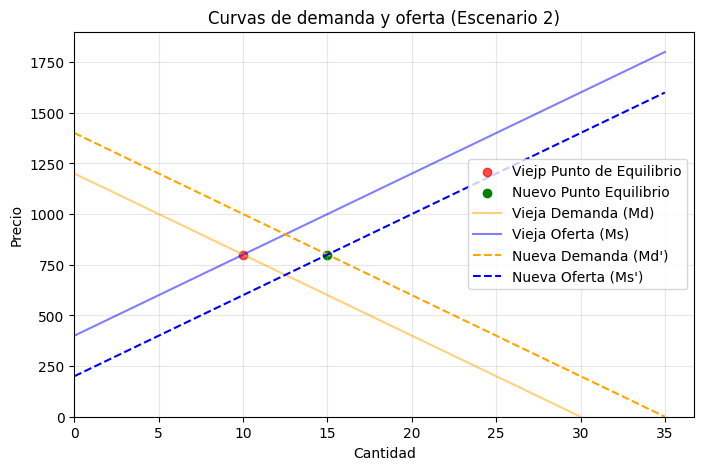

In [ ]:
#curva Demanda CLP (Md)
Md_1 = lambda x: 1400 -40*x
#curva oferta CLP (Ms)
Ms_1 = lambda x: 200 + 40*x
#equilibrio
E_1 = 15

# Array de tamano para el eje x
size = np.linspace(0, 35, 400)

# Grafica de ambas curvas
plt.figure(figsize=(8, 5))
plt.scatter(E, 800, color="red",  label="Viejp Punto de Equilibrio", alpha=0.7)

plt.scatter(E_1, 800, color="Green",  label="Nuevo Punto Equilibrio")

plt.plot(size, Md(size),color="Orange", label="Vieja Demanda (Md)",alpha=0.5)
plt.plot(size, Ms(size),color="Blue", label="Vieja Oferta (Ms)",alpha=0.5)
plt.plot(size, Md_1(size),color="Orange", label="Nueva Demanda (Md')",linestyle="--")
plt.plot(size, Ms_1(size),color="Blue", label="Nueva Oferta (Ms')",linestyle="--")
plt.xlabel("Cantidad")
plt.ylabel("Precio")
plt.title("Curvas de demanda y oferta (Escenario 2)")

plt.xlim(0)
plt.ylim(0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()